In [26]:
import cv2
import pytesseract as ts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pytesseract import Output

In [24]:
# Fonte calibri para melhor interpretação

from PIL import ImageFont, ImageDraw, Image
fonte = '/content/calibri.ttf'

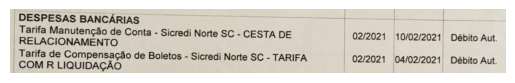

In [7]:
# Carregamento da imagem -- conversão para RGB -- Exposição via matplotlib
img = cv2.imread('tabela_teste.jpg')

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.axis('off')
plt.show()

In [ ]:
# Conversão para o tipo Data -- extração de datas da imagem
config_tesseract = "--tessdata-dir tessdata"
resultado = ts.image_to_data(rgb, config=config_tesseract, lang="por", output_type=Output.DICT)
resultado

In [11]:
padrao_data = r'^(0[1-9]|[12][0-9]|3[01])/(0[1-9]|1[012])/(19|20)\d\d$'

In [36]:
min_conf = 40

In [20]:
def caixa_texto(resultado, img, cor = (255, 100, 0)):
  x = resultado['left'][i]
  y = resultado['top'][i]
  w = resultado['width'][i]
  h = resultado['height'][i]

  cv2.rectangle(img, (x, y), (x + w, y + h), cor, 2)

  return x, y, img

In [22]:
def escreve_texto(texto, x, y, img, fonte, tamanho_texto=32):
  fonte = ImageFont.truetype(fonte, tamanho_texto)
  img_pil = Image.fromarray(img)
  draw = ImageDraw.Draw(img_pil)
  draw.text((x, y - tamanho_texto), texto, font = fonte)
  img = np.array(img_pil)
  return img

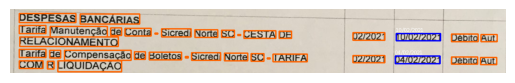

In [34]:
datas = []
img_copia = rgb.copy()
for i in range(0, len(resultado['text'])):
  confianca = int(resultado['conf'][i])
  if confianca > min_conf:
    texto = resultado['text'][i]
    if re.match(padrao_data, texto):
      x, y, img = caixa_texto(resultado, img_copia, (0,0,255))
      img_copia = escreve_texto(texto, x, y, img_copia, fonte, 12)
      datas.append(texto)
    else:
      x, y, img_copia = caixa_texto(resultado, img_copia)
        
plt.imshow(img_copia)
plt.axis('off')
plt.show()

In [35]:
datas

['10/02/2021', '04/02/2021']